# 01 · Exploración de datos — ModaModerna

In [91]:
# Minianaconda: algunas librerías pueden no funcionar correctamente con determinadas versiones de Python. 
# Para evitar estos problemas, se utiliza Miniconda, que permite utilizar las librerías necesarias para el proyecto 
# sin problemas de compatibilidad.


# Librerías nativas de Python
import os

# Manipulación y análisis de datos
import numpy as np
import pandas as pd

# Gráficos y visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar opciones para que Pandas no corte las columnas ni la pantalla
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Tema global de gráficos
sns.set_theme(style='whitegrid', palette='colorblind')
#  sns.set_theme() → establece un tema visual global para los gráficos de Seaborn.
#  style='whitegrid' → pone un fondo blanco con una cuadrícula.
#  palette='colorblind' → utiliza una paleta de colores pensada para ser más accesible para personas con daltonismo.

In [92]:
# Cargar los archivos
# Evitamos transformaciones previas en la carga (como sep=',', decimal='.', encoding='utf-8', dtype={'id': str}, parse_dates=['fecha'] o na_values=['N/A']).
# Motivo: no conocemos la estructura del archivo (desconocemos nombres de columnas, delimitadores o nombres de IDs).
# Cargar sin transformaciones previas permite abordar las problemáticas en exploración y limpieza con total certeza.

clientes = pd.read_csv('datos/clientes.csv')          
productos = pd.read_csv('datos/productos.csv')        
campana = pd.read_csv('datos/campana.csv')            
pedidos = pd.read_csv('datos/pedidos.csv')            
lineas_pedido = pd.read_csv('datos/lineas_pedido.csv')
devoluciones = pd.read_csv('datos/devoluciones.csv')  
visitas_web = pd.read_csv('datos/visitas_web.csv')    

# Tabla clientes: Exploración

In [93]:
# Diagnósticode la Tabla (Macro: a nivel general, sin entrar en detalle de cada columna)
# El diagnóstico general de la tabla permite identificar problemas de calidad de datos, como valores nulos, duplicados, tipos de datos incorrectos o inconsistencias en los formatos. Esto es crucial para planificar la limpieza y transformación de los datos antes de cualquier análisis o modelado.

print("Dimensiones del dataset (filas, columnas):") 
print(clientes.shape)

print("\nInformación general del dataset:")
clientes.info()
# Sin print porque info ya muestra el resultado en pantalla

print("\nPrimeras filas del dataset:")
print(clientes.head())

print("\nNúmero de valores nulos por columna:")
print(clientes.isnull().sum())

print("\nPorcentaje de valores nulos por columna:")
print(clientes.isnull().mean() * 100)

print("\nNúmero de filas duplicadas:")
print(clientes.duplicated().sum())

print("\nPorcentaje de filas duplicadas:")
print(clientes.duplicated().mean() * 100)

# (50000, 5)
# Tipo de fecha incorrecto (object en vez de datetime64) y cliente_id es un identificador, pasar a str.
# Se observan errores de formato en género (masculino/m/M) → 3 variantes para 1 de las dos categorías reales.
# Sin nulos en ninguna columna.
# Sin filas duplicadas.
# Se observa variación en la misma ciudad (barcelona/Barcelona aparece 2 veces cuando en realidad Barcelona es una sola ciudad).
# la diferencia se debe a mayúsculas/minúsculas.
# El formato de fecha es inconsistente(mixta): yyyy-mm-dd y dd/mm/yyyy.

Dimensiones del dataset (filas, columnas):
(50000, 5)

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   cliente_id      50000 non-null  int64 
 1   fecha_registro  50000 non-null  object
 2   ciudad          50000 non-null  object
 3   genero          50000 non-null  object
 4   edad            50000 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 1.9+ MB

Primeras filas del dataset:
   cliente_id fecha_registro                     ciudad     genero  edad
0      100000     27/02/2024                  barcelona  masculino    34
1      100001     2024-10-28                       Reus          m    32
2      100002     2024-08-24                     lleida          f    38
3      100003     2023-10-23  L'Hospitalet de Llobregat          m    21
4      100004     01/09/2022                  Barcel

Géneros únicos: ['masculino' 'm' 'f' 'M' 'F' 'Masculino' 'femenino' 'Femenino']
Ciudades únicas: ['barcelona' 'Reus' 'lleida' "L'Hospitalet de Llobregat" 'Barcelona'
 'BARCELONA' 'reus' "l'hospitalet de llobregat" 'Lleida' 'vic' 'Tarragona'
 'Terrassa' 'manresa' 'girona' 'Sabadell' 'Badalona' 'terrassa'
 'Sant Cugat del Vallès' 'Manresa' 'REUS' 'SANT CUGAT DEL VALLÈS'
 'sabadell' 'SABADELL' 'Vic' 'badalona' 'Girona' 'MANRESA' 'tarragona'
 'LLEIDA' 'VIC' 'TERRASSA' 'GIRONA' 'Mataró' 'sant cugat del vallès'
 'BADALONA' 'TARRAGONA' 'mataró' 'MATARÓ' "L'HOSPITALET DE LLOBREGAT"]
min        -9.000000
max       299.000000
mean       34.685060
median     34.000000
std        15.167199
Name: edad, dtype: float64


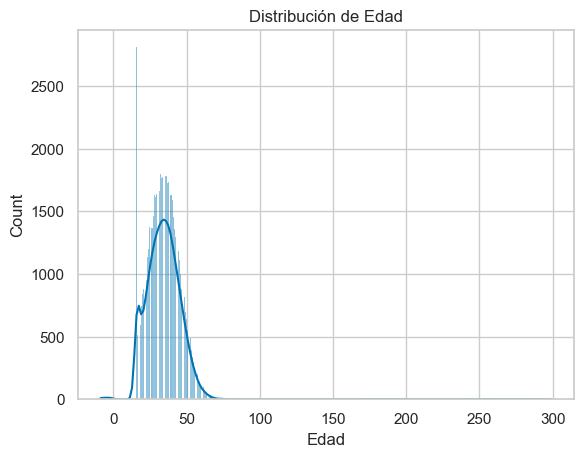

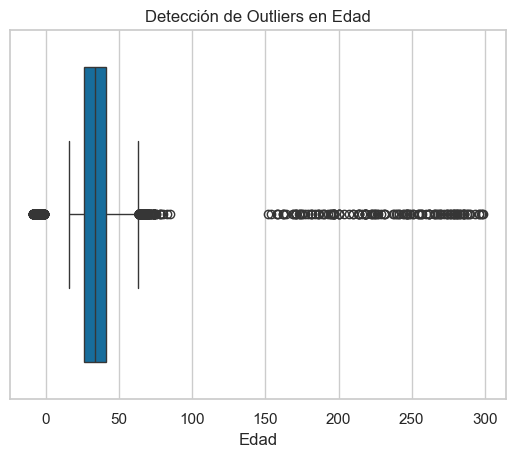

In [94]:
# Diagnóstico de la Tabla (Micro: a nivel de cada columna)
# El diagnostico micro permite profundizar en los problemas detectados en el diagnóstico macro, para poder abordarlos de manera efectiva en la limpieza de datos.
# En el diagnóstico micro se analizan los valores únicos de cada columna, rangos numéricos y outliers, y se visualizan gráficos para detectar valores atípicos.

# Clientes
generos_unicos = clientes['genero'].unique()
print('Géneros únicos:', generos_unicos)

ciudades_unicas = clientes['ciudad'].unique()
print('Ciudades únicas:', ciudades_unicas)

print(clientes['edad'].agg(['min', 'max', 'mean', 'median', 'std']))
# min - max: rango total (edades negativas e imposiblemente altas).
# mean vs median: próximas, la masa central de datos es simétrica y los valores anómalos son casos puntuales.

sns.histplot(data=clientes, x='edad', kde=True)
plt.title('Distribución de Edad')
plt.xlabel('Edad')
plt.show()

sns.boxplot(data=clientes, x='edad')
plt.title('Detección de Outliers en Edad')
plt.xlabel('Edad')
plt.show()

# Tabla productos: Exploración

In [95]:
# Diagnósticode la Tabla (Macro: a nivel general, sin entrar en detalle de cada columna)
# El diagnóstico general de la tabla permite identificar problemas de calidad de datos, como valores nulos, duplicados, tipos de datos incorrectos o inconsistencias en los formatos. Esto es crucial para planificar la limpieza y transformación de los datos antes de cualquier análisis o modelado.

# Diagnóstico General de la Tabla (Macro)
print("Dimensiones del dataset (filas, columnas):")
print(productos.shape)

print("\nInformación general del dataset:")
productos.info()
# Sin print porque info ya muestra el resultado en pantalla

print("\nPrimeras filas del dataset:")
print(productos.head())

print("\nNúmero de valores nulos por columna:")
print(productos.isnull().sum())

print("\nPorcentaje de valores nulos por columna:")
print(productos.isnull().mean() * 100)

print("\nNúmero de filas duplicadas:")
print(productos.duplicated().sum())

print("\nPorcentaje de filas duplicadas:")
print(productos.duplicated().mean() * 100)

# (600, 7)
# producto_id es un identificador, pasar a str.
# Se observan errores tipográficos en temporada (oi25 no en el mismo formato que los demás).
# Sin nulos en ninguna columna.
# Sin filas duplicadas.

Dimensiones del dataset (filas, columnas):
(600, 7)

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   producto_id     600 non-null    int64  
 1   nombre          600 non-null    object 
 2   categoria       600 non-null    object 
 3   temporada       600 non-null    object 
 4   coleccion       600 non-null    object 
 5   coste_unitario  600 non-null    float64
 6   precio_base     600 non-null    float64
dtypes: float64(2), int64(1), object(4)
memory usage: 32.9+ KB

Primeras filas del dataset:
   producto_id          nombre   categoria    temporada         coleccion  coste_unitario  precio_base
0         1001  Sandalia Petra     Zapatos         oi25      Mediterráneo            9.67        24.95
1         1002   Sandalia Flor     Zapatos     verano25  Fiesta Diciembre           20.46        52.00
2   

Categorías únicas: ['Zapatos' 'calzado' 'accesorios' 'zapatos' 'Vestidos' 'Calzado' 'Abrigos'
 'abrigo' 'vestidos' 'vestido' 'Pantalones' 'Camisetas' 'camiseta'
 'abrigos' 'pantalon' 'Jerseis' 'pantalones' 'camisetas' 'Complementos'
 'falda' 'Accesorios' 'Faldas' 'accesorio' 'jerséis' 'faldas' 'jerseis'
 'jersey' 'VESTIDOS' 'complementos']
Temporadas únicas: ['oi25' 'verano25' 'invierno25' 'verano 2025' 'verano' 'invierno 2025'
 'otoño invierno 2025' 'ss25']
Colecciones únicas: ['Mediterráneo' 'Fiesta Diciembre' 'Noche' 'Cápsula Sol' 'Playa Club'
 'Urban SS25' 'Invierno Cálido' 'Denim' 'Básicos' 'Atelier' 'Punto & Lana']
min        12.650000
max       113.940000
mean       56.690783
median     55.860000
std        25.929781
Name: precio_base, dtype: float64
min        6.030000
max       44.980000
mean      25.809733
median    25.575000
std       11.547932
Name: coste_unitario, dtype: float64


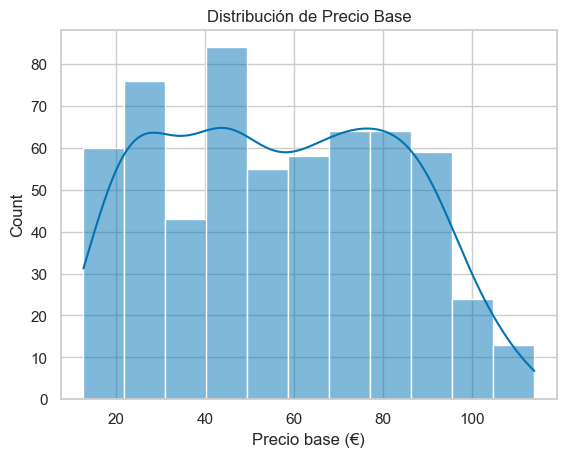

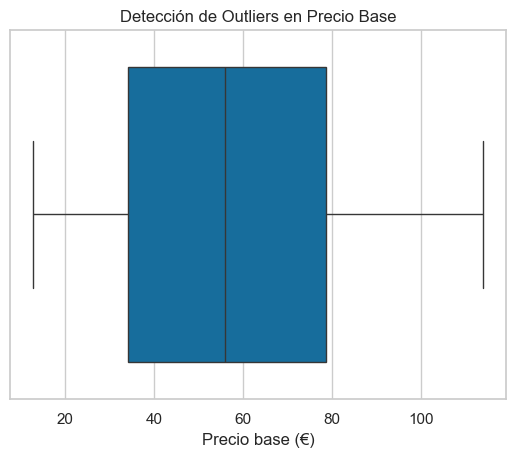

In [96]:
# Diagnóstico de la Tabla (Micro: a nivel de cada columna)
# El diagnostico micro permite profundizar en los problemas detectados en el diagnóstico macro, para poder abordarlos de manera efectiva en la limpieza de datos.
# En el diagnóstico micro se analizan los valores únicos de cada columna, rangos numéricos y outliers, y se visualizan gráficos para detectar valores atípicos.

# Productos
categorias_unicas = productos['categoria'].unique()
print('Categorías únicas:', categorias_unicas)

temporadas_unicas = productos['temporada'].unique()
print('Temporadas únicas:', temporadas_unicas)

colecciones_unicas = productos['coleccion'].unique()
print('Colecciones únicas:', colecciones_unicas)

print(productos['precio_base'].agg(['min', 'max', 'mean', 'median', 'std']))
print(productos['coste_unitario'].agg(['min', 'max', 'mean', 'median', 'std']))

sns.histplot(data=productos, x='precio_base', kde=True)
plt.title('Distribución de Precio Base')
plt.xlabel('Precio base (€)')
plt.show()

sns.boxplot(data=productos, x='precio_base')
plt.title('Detección de Outliers en Precio Base')
plt.xlabel('Precio base (€)')
plt.show()

# Tabla campaña: Exploración

In [97]:
# Diagnósticode la Tabla (Macro: a nivel general, sin entrar en detalle de cada columna)
# El diagnóstico general de la tabla permite identificar problemas de calidad de datos, como valores nulos, duplicados, tipos de datos incorrectos o inconsistencias en los formatos. Esto es crucial para planificar la limpieza y transformación de los datos antes de cualquier análisis o modelado.

# Diagnóstico General de la Tabla (Macro)
print("Dimensiones del dataset (filas, columnas):")
print(campana.shape)

print("\nInformación general del dataset:")
campana.info()
# Sin print porque info ya muestra el resultado en pantalla

print("\nPrimeras filas del dataset:")
print(campana.head())

print("\nNúmero de valores nulos por columna:")
print(campana.isnull().sum())

print("\nPorcentaje de valores nulos por columna:")
print(campana.isnull().mean() * 100)

print("\nNúmero de filas duplicadas:")
print(campana.duplicated().sum())

print("\nPorcentaje de filas duplicadas:")
print(campana.duplicated().mean() * 100)

# (4, 8)
# Fechas mal tipadas (object), campana_id y presupuesto con tipo incorrecto.
# Sin nulos.
# Sin filas duplicadas.

Dimensiones del dataset (filas, columnas):
(4, 8)

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   campana_id           4 non-null      int64  
 1   nombre               4 non-null      object 
 2   tipo                 4 non-null      object 
 3   fecha_inicio         4 non-null      object 
 4   fecha_fin            4 non-null      object 
 5   canal                4 non-null      object 
 6   presupuesto          4 non-null      object 
 7   ventas_ano_anterior  4 non-null      float64
dtypes: float64(1), int64(1), object(6)
memory usage: 388.0+ bytes

Primeras filas del dataset:
   campana_id                 nombre          tipo fecha_inicio   fecha_fin      canal presupuesto  ventas_ano_anterior
0           1  Rebajas Invierno 2025       rebajas   2025-01-07  2025-01-28      email     68000.0  

Nombres únicos: ['Rebajas Invierno 2025' 'Rebajas Verano 2025' 'Black Friday 2025'
 'Navidad 2025']
Tipos únicos: ['rebajas' 'black_friday' 'navidad']
Canales únicos: ['email' 'instagram' 'google']


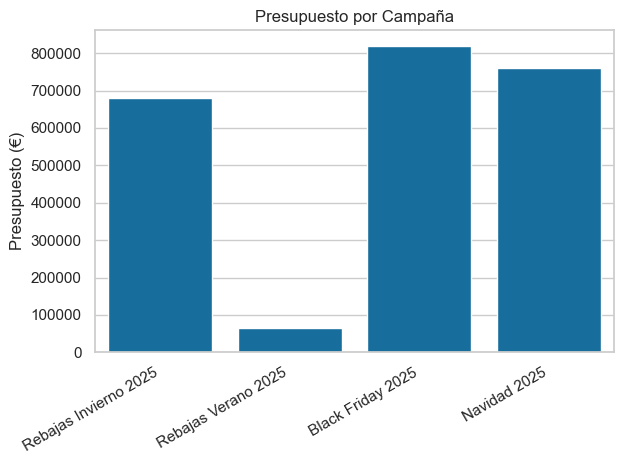

In [98]:
# Diagnóstico de la Tabla (Micro: a nivel de cada columna)
# El diagnostico micro permite profundizar en los problemas detectados en el diagnóstico macro, para poder abordarlos de manera efectiva en la limpieza de datos.
# En el diagnóstico micro se analizan los valores únicos de cada columna, rangos numéricos y outliers, y se visualiza con un gráfico para detectar valores atípicos.

# Campaña
nombres_unicos = campana['nombre'].unique()
print('Nombres únicos:', nombres_unicos)
tipos_unicos = campana['tipo'].unique()
print('Tipos únicos:', tipos_unicos)
canales_unicos = campana['canal'].unique()
print('Canales únicos:', canales_unicos)

# Investigamos la columna numérica
# ---------------------------------

# 'presupuesto'
# La columna está almacenada como texto (object) y presenta diferentes formatos:
# números sin formato moneda (ej. 68000.0) y números con formato moneda (ej. 64.000,00 €).
# En análisis de datos el formato sin moneda es el que necesitamos para poder realizar las estadísticas descriptivas.
# Podemos aplicar a la columna presupuesto una pequeña transformación para eliminar el símbolo de euro, el separador de miles y cambiar la coma decimal por un punto decimal.
# Después convertimos toda la columna a tipo numérico (float) con to_numeric.

campana['presupuesto'] = (
    campana['presupuesto']
        .str.replace('€', '', regex=False)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
        .str.strip()
)

campana['presupuesto'] = pd.to_numeric(
    campana['presupuesto'],
    errors='coerce'
)

campana['presupuesto'].agg(['min', 'max', 'mean', 'median', 'std'])

sns.barplot(
    data=campana,
    x='nombre',
    y='presupuesto'
)

plt.title('Presupuesto por Campaña')
plt.ylabel('Presupuesto (€)')
plt.xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Tabla pedidos: Exploración

In [ ]:
# Diagnósticode la Tabla (Macro: a nivel general, sin entrar en detalle de cada columna)
# El diagnóstico general de la tabla permite identificar problemas de calidad de datos, como valores nulos, duplicados, tipos de datos incorrectos o inconsistencias en los formatos. Esto es crucial para planificar la limpieza y transformación de los datos antes de cualquier análisis o modelado.

# Diagnóstico General de la Tabla (Macro)
print("Dimensiones del dataset (filas, columnas):")
print(pedidos.shape)

print("\nInformación general del dataset:")
pedidos.info()
# Sin print porque info ya muestra el resultado en pantalla

print("\nPrimeras filas del dataset:")
print(pedidos.head())

print("\nNúmero de valores nulos por columna:")
print(pedidos.isnull().sum())

print("\nPorcentaje de valores nulos por columna:")
print(pedidos.isnull().mean() * 100)

print("\nNúmero de filas duplicadas:")
print(pedidos.duplicated().sum())

print("\nPorcentaje de filas duplicadas:")
print(pedidos.duplicated().mean() * 100)

# (90000, 7)
# Fechas de pedido mal tipadas (object) e identificadores (pedido_id, cliente_id, campana_id) con formato incorrecto (deberían ser str).
# El identificador campana_id es de tipo float, pasar a int64 para eliminar el ".0" y después a texto(str).
# Nulos en campana_id: corresponden a pedidos realizados fuera de los periodos de campaña (venta orgánica),
# por lo que NO se deben imputar ni eliminar.
# Sin filas duplicadas.
# Variantes de formato en ciudad, mismo problema de mayúsculas/minúsculas que en clientes.
# Se observa fechas de pedido con formato mixto (yyyy-mm-dd y dd/mm/yyyy).

Dimensiones del dataset (filas, columnas):
(90000, 7)

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   pedido_id     90000 non-null  int64  
 1   cliente_id    90000 non-null  int64  
 2   fecha_pedido  90000 non-null  object 
 3   campana_id    34708 non-null  float64
 4   canal         90000 non-null  object 
 5   ciudad        90000 non-null  object 
 6   metodo_pago   90000 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 4.8+ MB

Primeras filas del dataset:
   pedido_id  cliente_id fecha_pedido  campana_id      canal                     ciudad metodo_pago
0     500001      106480   14/07/2025         2.0  instagram                        VIC     tarjeta
1     500002      123135   2025-11-13         NaN     google                  BARCELONA      paypal
2     500003      127034  

In [100]:
# Diagnóstico de la Tabla (Micro: a nivel de cada columna)
# El diagnostico micro permite profundizar en los problemas detectados en el diagnóstico macro, para poder abordarlos de manera efectiva en la limpieza de datos.
# En el diagnóstico micro se analizan los valores únicos de cada columna, formato de fechas y porcentaje de pedidos sin campaña.
# Sin gráficos porque no hay columnas numéricas en pedidos.

canales_unicos = pedidos['canal'].unique()
print('Canales únicos:', canales_unicos)
ciudades_unicas = pedidos['ciudad'].unique()
print('Ciudades únicas:', ciudades_unicas)
metodos_unicos = pedidos['metodo_pago'].unique()
print('Métodos de pago únicos:', metodos_unicos)

print("Muestra de fechas de pedido originales:")
print(pedidos['fecha_pedido'].head(10))
# Se confirma la mezcla de formatos yyyy-mm-dd y dd/mm/yyyy.

porcentaje_sin_campana = pedidos['campana_id'].isnull().mean() * 100
print('Porcentaje de pedidos sin campaña:', porcentaje_sin_campana)

Canales únicos: ['instagram' 'google' 'directo' 'email']
Ciudades únicas: ['VIC' 'BARCELONA' 'Sant Cugat del Vallès' 'Tarragona'
 "l'hospitalet de llobregat" 'Barcelona' 'GIRONA' 'Lleida' 'barcelona'
 'Manresa' 'Sabadell' "L'Hospitalet de Llobregat" 'Badalona' 'Girona'
 'Terrassa' 'lleida' 'badalona' 'TERRASSA' 'REUS' 'mataró' 'Reus'
 'tarragona' 'SANT CUGAT DEL VALLÈS' 'TARRAGONA' 'LLEIDA' 'terrassa'
 'SABADELL' "L'HOSPITALET DE LLOBREGAT" 'girona' 'Vic' 'sabadell'
 'manresa' 'MATARÓ' 'Mataró' 'MANRESA' 'reus' 'BADALONA'
 'sant cugat del vallès' 'vic']
Métodos de pago únicos: ['tarjeta' 'paypal' 'bizum']
Muestra de fechas de pedido originales:
0    14/07/2025
1    2025-11-13
2    2025-09-04
3    2025-11-03
4    2025-01-17
5    14/12/2025
6    2025-11-11
7    23/12/2025
8    2025-12-08
9    19/01/2025
Name: fecha_pedido, dtype: object
Porcentaje de pedidos sin campaña: 61.43555555555555


# Tabla líneas de pedido: Exploración

In [101]:
# Diagnósticode la Tabla (Macro: a nivel general, sin entrar en detalle de cada columna)
# El diagnóstico general de la tabla permite identificar problemas de calidad de datos, como valores nulos, duplicados, tipos de datos incorrectos o inconsistencias en los formatos. Esto es crucial para planificar la limpieza y transformación de los datos antes de cualquier análisis o modelado.

print("Dimensiones del dataset (filas, columnas):")
print(lineas_pedido.shape)

print("\nInformación general del dataset:")
lineas_pedido.info()
# Sin print porque info ya muestra el resultado en pantalla

print("\nPrimeras filas del dataset:")
print(lineas_pedido.head())

print("\nNúmero de valores nulos por columna:")
print(lineas_pedido.isnull().sum())

print("\nPorcentaje de valores nulos por columna:")
print(lineas_pedido.isnull().mean() * 100)

print("\nNúmero de filas duplicadas:")
print(lineas_pedido.duplicated().sum())

print("\nPorcentaje de filas duplicadas:")
print(lineas_pedido.duplicated().mean() * 100)

# (181637, 7)
# precio_unitario y descuento_pct están tipados como object (texto) en vez de numéricos.
# ids (linea_id, pedido_id, producto_id) numéricos, deberían ser str.
# Sin nulos en ninguna columna.
# Sin filas duplicadas.

Dimensiones del dataset (filas, columnas):
(181637, 7)

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181637 entries, 0 to 181636
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   linea_id         181637 non-null  int64 
 1   pedido_id        181637 non-null  int64 
 2   producto_id      181637 non-null  int64 
 3   talla            181637 non-null  object
 4   cantidad         181637 non-null  int64 
 5   precio_unitario  181637 non-null  object
 6   descuento_pct    181637 non-null  object
dtypes: int64(4), object(3)
memory usage: 9.7+ MB

Primeras filas del dataset:
   linea_id  pedido_id  producto_id talla  cantidad precio_unitario descuento_pct
0    900001     500001         1567    XS         1         20,86 €           50%
1    900002     500002         1463     S         1         66,70 €             0
2    900003     500002         1313     M         1           

Tallas únicas: ['XS' 'S' 'M' 'L' '36' '42' 'XL' '39' '38' '37' '40' '41']
['20,86 €', '66,70 €', '35.42', '44,57 €', '53,11 €', '76.44', '47.93', '24,26 €', '31.93', '90.16']
Valores únicos de descuento_pct: ['50%' '0' '0.0' '10%' '0.3' '30%' '20%' '0.5' '0.2' '0.1' '40%' '0.4']
min     1.000000
max     3.000000
mean    1.270551
Name: cantidad, dtype: float64


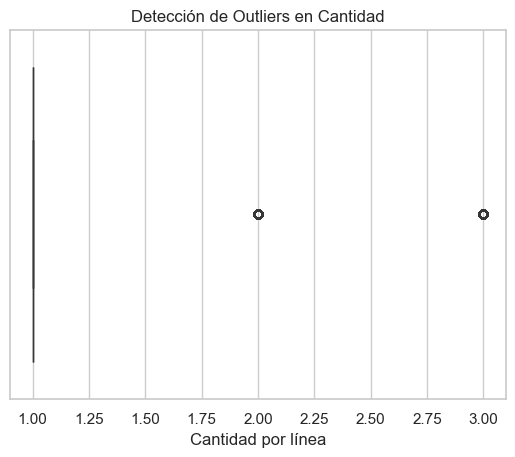

In [102]:
# Diagnóstico de la Tabla (Micro: a nivel de cada columna)
# El diagnostico micro permite profundizar en los problemas detectados en el diagnóstico macro, para poder abordarlos de manera efectiva en la limpieza de datos.
# En el diagnóstico micro se analizan los valores únicos de cada columna, outliers y se visualiza con un gráfico para detectar valores atípicos.

tallas_unicas = lineas_pedido['talla'].unique()
print('Tallas únicas:', tallas_unicas)
# No es un error de formato: conviven dos escalas de talla distintas según el producto (ropa: XS-XL / calzado: 36-42).

print(lineas_pedido['precio_unitario'].head(10).tolist())
# Se mezclan dos formatos: número plano ("35.42") y texto con símbolo de moneda y coma decimal ("20,86 €").

descuentos_unicos = lineas_pedido['descuento_pct'].unique()
print('Valores únicos de descuento_pct:', descuentos_unicos)
# Se mezclan tres formas de representar lo mismo: fracción decimal ("0.0") y porcentaje en texto ("50%")

print(lineas_pedido['cantidad'].agg(['min', 'max', 'mean']))

sns.boxplot(data=lineas_pedido, x='cantidad')
plt.title('Detección de Outliers en Cantidad')
plt.xlabel('Cantidad por línea')
plt.show()

# Tabla devoluciones: Exploración

In [103]:
# Diagnósticode la Tabla (Macro: a nivel general, sin entrar en detalle de cada columna)
# El diagnóstico general de la tabla permite identificar problemas de calidad de datos, como valores nulos, duplicados, tipos de datos incorrectos o inconsistencias en los formatos. Esto es crucial para planificar la limpieza y transformación de los datos antes de cualquier análisis o modelado.

print("Dimensiones del dataset (filas, columnas):")
print(devoluciones.shape)

print("\nInformación general del dataset:")
devoluciones.info()
# Sin print porque info ya muestra el resultado en pantalla

print("\nPrimeras filas del dataset:")
print(devoluciones.head())

print("\nNúmero de valores nulos por columna:")
print(devoluciones.isnull().sum())

print("\nPorcentaje de valores nulos por columna:")
print(devoluciones.isnull().mean() * 100)

print("\nNúmero de filas duplicadas:")
print(devoluciones.duplicated().sum())

print("\nPorcentaje de filas duplicadas:")
print(devoluciones.duplicated().mean() * 100)

# (45409, 5)
# Fecha de devolución mal tipada (object), ids numéricos deberían ser str.
# Sin nulos en ninguna columna.
# Sin filas duplicadas.
# Se observan diferentes variantes de formato en talla (números y letras, no necesariamente debe interpretarse como un error).
# Se observa fechas de devolución con formato mixto (yyyy-mm-dd y dd/mm/yyyy).

Dimensiones del dataset (filas, columnas):
(45409, 5)

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45409 entries, 0 to 45408
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   devolucion_id     45409 non-null  int64 
 1   linea_id          45409 non-null  int64 
 2   fecha_devolucion  45409 non-null  object
 3   talla             45409 non-null  object
 4   motivo            45409 non-null  object
dtypes: int64(2), object(3)
memory usage: 1.7+ MB

Primeras filas del dataset:
   devolucion_id  linea_id fecha_devolucion talla            motivo
0         700001   1009435       16/12/2025     S  talla incorrecta
1         700002    927467       2025-03-24    42           defecto
2         700003    994165       02/01/2026     L  talla incorrecta
3         700004    913307       30/08/2025     M  no me queda bien
4         700005    956270       27/11/2025     S           def

Tallas únicas: ['S' '42' 'L' 'M' 'XL' 'XS' '37' '41' '40' '36' 'xs' 'l' '39' 'xl' '38'
 'm' 's']
Motivos únicos: ['talla incorrecta' 'defecto' 'no me queda bien' 'color distinto'
 'no me gusta' 'cambió de opinión' 'talla' 'me queda pequeño']
Muestra de fechas de devolución originales:
0    16/12/2025
1    2025-03-24
2    02/01/2026
3    30/08/2025
4    27/11/2025
5    2025-12-02
6    2025-09-11
7    22/12/2025
8    2026-01-15
9    2025-05-18
Name: fecha_devolucion, dtype: object
motivo
talla incorrecta     27.243498
no me gusta          21.229272
no me queda bien     19.670109
defecto              11.803827
cambió de opinión     8.976194
color distinto        8.110727
talla                 1.977582
me queda pequeño      0.988791
Name: proportion, dtype: float64


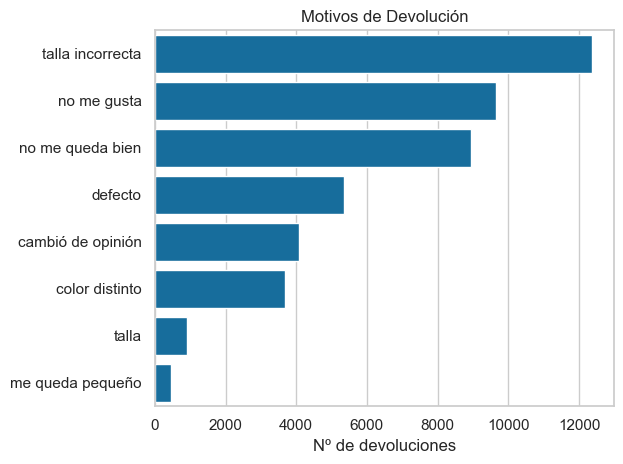

In [104]:
# Diagnóstico de la Tabla (Micro: a nivel de cada columna)
# El diagnostico micro permite profundizar en los problemas detectados en el diagnóstico macro, para poder abordarlos de manera efectiva en la limpieza de datos.
# En el diagnóstico micro se analizan los valores únicos de cada columna, formato de fechas y se visualiza con un gráfico para detectar valores atípicos.

tallas_unicas = devoluciones['talla'].unique()
print('Tallas únicas:', tallas_unicas)
# 17 variantes para las mismas 12 tallas reales: el problema es mayúsculas/minúsculas.

motivos_unicos = devoluciones['motivo'].unique()
print('Motivos únicos:', motivos_unicos)

print("Muestra de fechas de devolución originales:")
print(devoluciones['fecha_devolucion'].head(10))

print(devoluciones['motivo'].value_counts(normalize=True) * 100)
sns.countplot(data=devoluciones, y='motivo', order=devoluciones['motivo'].value_counts().index)
plt.title('Motivos de Devolución')
plt.xlabel('Nº de devoluciones')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Tabla visitas web: Exploración

In [105]:
# Diagnósticode la Tabla (Macro: a nivel general, sin entrar en detalle de cada columna)
# El diagnóstico general de la tabla permite identificar problemas de calidad de datos, como valores nulos, duplicados, tipos de datos incorrectos o inconsistencias en los formatos. Esto es crucial para planificar la limpieza y transformación de los datos antes de cualquier análisis o modelado.

print("Dimensiones del dataset (filas, columnas):")
print(visitas_web.shape)

print("\nInformación general del dataset:")
visitas_web.info()
# Sin print porque info ya muestra el resultado en pantalla

print("\nPrimeras filas del dataset:")
print(visitas_web.head())

print("\nNúmero de valores nulos por columna:")
print(visitas_web.isnull().sum())

print("\nPorcentaje de valores nulos por columna:")
print(visitas_web.isnull().mean() * 100)

print("\nNúmero de filas duplicadas:")
print(visitas_web.duplicated().sum())

print("\nPorcentaje de filas duplicadas:")
print(visitas_web.duplicated().mean() * 100)

# (1460, 3)
# fecha mal tipada (object).
# Nulos en sesiones: corresponden a días sin registro, no es un error de negocio.
# Sin filas duplicadas.

Dimensiones del dataset (filas, columnas):
(1460, 3)

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   fecha     1460 non-null   object 
 1   canal     1460 non-null   object 
 2   sesiones  1412 non-null   float64
dtypes: float64(1), object(2)
memory usage: 34.3+ KB

Primeras filas del dataset:
        fecha      canal  sesiones
0  2025-01-01  instagram    2557.0
1  2025-01-01     google    1696.0
2  2025-01-01      email     647.0
3  2025-01-01    directo     687.0
4  2025-01-02  instagram    2297.0

Número de valores nulos por columna:
fecha        0
canal        0
sesiones    48
dtype: int64

Porcentaje de valores nulos por columna:
fecha       0.000000
canal       0.000000
sesiones    3.287671
dtype: float64

Número de filas duplicadas:
0

Porcentaje de filas duplicadas:
0.0


Canales únicos: ['instagram' 'google' 'email' 'directo']
min        468.000000
max       7644.000000
mean      1672.604108
median    1413.500000
std       1252.248424
Name: sesiones, dtype: float64


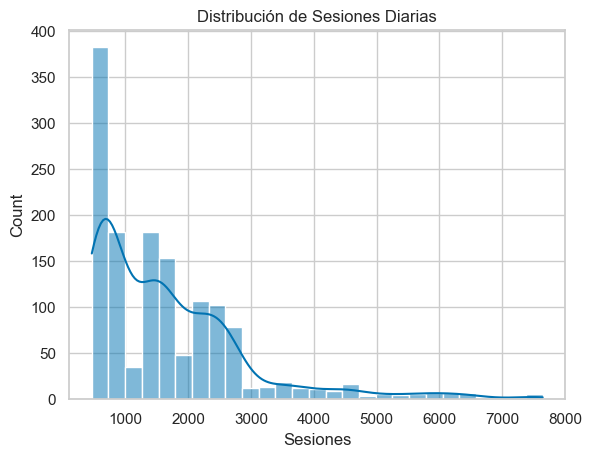

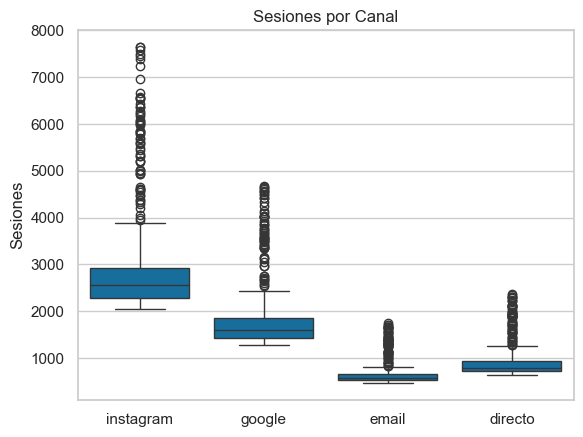

In [106]:
# Diagnóstico de la Tabla (Micro: a nivel de cada columna)
# El diagnostico micro permite profundizar en los problemas detectados en el diagnóstico macro, para poder abordarlos de manera efectiva en la limpieza de datos.
# En el diagnóstico micro se analizan los valores únicos de cada columna, rangos y se visualiza con gráficos para detectar valores atípicos.

canales_unicos = visitas_web['canal'].unique()
print('Canales únicos:', canales_unicos)

print(visitas_web['sesiones'].agg(['min', 'max', 'mean', 'median', 'std']))

sns.histplot(data=visitas_web, x='sesiones', kde=True)
plt.title('Distribución de Sesiones Diarias')
plt.xlabel('Sesiones')
plt.show()

sns.boxplot(data=visitas_web, x='canal', y='sesiones')
plt.title('Sesiones por Canal')
plt.xlabel('')
plt.ylabel('Sesiones')
plt.show()